# CSE5104 Project 1 — Concrete Compressive Strength (Linear Regression)

This notebook contains a **from-scratch gradient descent** implementation for:
- **Part B:** univariate + multivariate linear regression (MSE objective), with both standardized and raw predictors.
- **Part C:** OLS regression analysis with **p-values** (via `statsmodels`) under raw, standardized, and log(x+1) transformations.

Dataset: Concrete Compressive Strength (UCI).  
Train/Test split: **rows 501–630 (1-indexed)** are test; the remaining 900 rows are training.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error
import statsmodels.api as sm

# Reproducibility
np.random.seed(0)

In [3]:
import os
print(os.getcwd())

/Users/kevinzhang/Desktop/WashU/WashU_2026_Spring/DataMining/Project


In [4]:
# Load data
path = "/Users/kevinzhang/Desktop/WashU/WashU_2026_Spring/DataMining/Project/Concrete_Data.csv"
df = pd.read_csv(path)

# Rename columns (short names)
df.columns = [
    "Cement",
    "Blast_Furnace_Slag",
    "Fly_Ash",
    "Water",
    "Superplasticizer",
    "Coarse_Aggregate",
    "Fine_Aggregate",
    "Age",
    "Concrete_Strength",
]

df.head()

,Cement,Blast_Furnace_Slag,Fly_Ash,Water,Superplasticizer,Coarse_Aggregate,Fine_Aggregate,Age,Concrete_Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [5]:
# Train/test split: rows 501–630 (1-indexed) => indices 501..630 in pandas
test_indices = list(range(501, 631))
train_indices = list(range(0, 501)) + list(range(631, 1030))

train_df = df.iloc[train_indices].reset_index(drop=True)
test_df  = df.iloc[test_indices].reset_index(drop=True)

X_train = train_df.drop(columns=["Concrete_Strength"])
y_train = train_df["Concrete_Strength"].to_numpy(dtype=float)

X_test  = test_df.drop(columns=["Concrete_Strength"])
y_test  = test_df["Concrete_Strength"].to_numpy(dtype=float)

X_train.shape, X_test.shape

((900, 8), (130, 8))

In [6]:
# Helpers
def mse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred)

def r2(y_true, y_pred):
    # Variance explained: 1 - MSE / Var(y)
    return 1 - mse(y_true, y_pred) / np.var(y_true, ddof=0)

def standardize_train_test(x_train, x_test):
    mu = np.mean(x_train)
    sd = np.std(x_train, ddof=0)
    if sd == 0:
        sd = 1.0
    return (x_train - mu) / sd, (x_test - mu) / sd, mu, sd

In [7]:
# Gradient Descent (from scratch)

def gd_univariate(x, y, alpha=0.01, n_iter=2000):
    """Fit y ≈ m*x + b by gradient descent on MSE."""
    m = 0.0
    b = 0.0
    n = len(x)

    for _ in range(n_iter):
        y_pred = m * x + b

        # Guard: if diverged, stop and signal failure
        if np.any(np.isnan(y_pred)) or np.any(np.isinf(y_pred)):
            return np.nan, np.nan

        err = y_pred - y
        m_grad = (2 / n) * np.dot(err, x)
        b_grad = (2 / n) * np.sum(err)

        m -= alpha * m_grad
        b -= alpha * b_grad

        if np.isnan(m) or np.isnan(b) or np.isinf(m) or np.isinf(b):
            return np.nan, np.nan

    return m, b


def gd_multivariate(X, y, alpha=0.01, n_iter=2000, return_history=False):
    """Fit y ≈ Xw + b by gradient descent on MSE. (No intercept column; b is separate.)"""
    n, p = X.shape
    w = np.zeros(p)
    b = 0.0
    history = []

    for _ in range(n_iter):
        y_pred = X @ w + b

        if np.any(np.isnan(y_pred)) or np.any(np.isinf(y_pred)):
            w[:] = np.nan
            b = np.nan
            break

        err = y_pred - y
        w_grad = (2 / n) * (X.T @ err)
        b_grad = (2 / n) * np.sum(err)

        w -= alpha * w_grad
        b -= alpha * b_grad

        if return_history:
            history.append(mse(y, y_pred))

        if np.any(np.isnan(w)) or np.any(np.isinf(w)) or np.isnan(b) or np.isinf(b):
            w[:] = np.nan
            b = np.nan
            break

    return (w, b, history) if return_history else (w, b)

## Part B — Q1 Univariate Models

### Q1.1 Set 1 (Standardized predictors, raw response)
We standardize each predictor **using training mean/std** and fit one univariate model per predictor.

In [8]:
results_set1 = []

for feat in X_train.columns:
    xtr = X_train[feat].to_numpy(dtype=float)
    xte = X_test[feat].to_numpy(dtype=float)

    xtr_s, xte_s, _, _ = standardize_train_test(xtr, xte)

    m_hat, b_hat = gd_univariate(xtr_s, y_train, alpha=0.01, n_iter=2000)

    yhat_tr = m_hat * xtr_s + b_hat
    yhat_te = m_hat * xte_s + b_hat

    results_set1.append({
        "feature": feat,
        "m": m_hat,
        "b": b_hat,
        "train_MSE": mse(y_train, yhat_tr),
        "train_R2": r2(y_train, yhat_tr),
        "test_MSE": mse(y_test, yhat_te),
        "test_R2": r2(y_test, yhat_te),
    })

df_set1 = pd.DataFrame(results_set1).sort_values("train_R2", ascending=False)
df_set1

,feature,m,b,train_MSE,train_R2,test_MSE,test_R2
0,Cement,8.576303,36.972,203.527354,0.265457,268.103306,-0.231305
7,Age,5.821494,36.972,243.190535,0.122310,298.418106,-0.370530
4,Superplasticizer,5.276505,36.972,249.238818,0.100482,195.642298,0.101483
3,Water,-4.586169,36.972,256.047375,0.075909,260.305841,-0.195494
2,Fly_Ash,-3.425128,36.972,265.348821,0.042340,382.789302,-0.758017
1,Blast_Furnace_Slag,2.622250,36.972,270.204129,0.024817,309.086336,-0.419525
6,Fine_Aggregate,-2.507650,36.972,270.792016,0.022695,283.227283,-0.300764
5,Coarse_Aggregate,-2.128654,36.972,272.549158,0.016353,275.934471,-0.267271


### Q1.2 Set 2 (Raw predictors, raw response)
Because raw predictors have very different scales, we **search a few learning rates** per feature and **skip diverged runs** (NaN/inf predictions).

In [9]:
candidate_lrs = [1e-8, 1e-7, 1e-6, 1e-5, 1e-4]
results_set2 = []

for feat in X_train.columns:
    xtr = X_train[feat].to_numpy(dtype=float)
    xte = X_test[feat].to_numpy(dtype=float)

    best = None

    for lr in candidate_lrs:
        m_hat, b_hat = gd_univariate(xtr, y_train, alpha=lr, n_iter=30000)
        if np.isnan(m_hat) or np.isnan(b_hat):
            continue

        yhat_tr = m_hat * xtr + b_hat
        yhat_te = m_hat * xte + b_hat

        # Guard: skip NaN/inf predictions (prevents ValueError in MSE/R2)
        if (np.any(np.isnan(yhat_tr)) or np.any(np.isinf(yhat_tr)) or
            np.any(np.isnan(yhat_te)) or np.any(np.isinf(yhat_te))):
            continue

        row = {
            "feature": feat,
            "lr": lr,
            "m": m_hat,
            "b": b_hat,
            "train_MSE": mse(y_train, yhat_tr),
            "train_R2": r2(y_train, yhat_tr),
            "test_MSE": mse(y_test, yhat_te),
            "test_R2": r2(y_test, yhat_te),
        }

        if (best is None) or (row["train_R2"] > best["train_R2"]):
            best = row

    results_set2.append(best)

df_set2 = pd.DataFrame(results_set2).sort_values("train_R2", ascending=False)
df_set2

,feature,lr,m,b,train_MSE,train_R2,test_MSE,test_R2
0,Cement,0.000010,0.122943,1.065427,226.478035,0.182627,256.454834,-0.177807
7,Age,0.000100,0.100509,31.894176,243.507334,0.121167,293.593360,-0.348372
4,Superplasticizer,0.000100,1.078855,28.556117,251.618822,0.091892,174.435514,0.198879
2,Fly_Ash,0.000100,-0.042236,38.605938,266.488474,0.038227,348.326936,-0.599744
5,Coarse_Aggregate,0.000001,0.037544,0.024135,298.113779,-0.075911,344.216734,-0.580867
6,Fine_Aggregate,0.000001,0.046955,0.040483,311.593985,-0.124562,332.910242,-0.528940
3,Water,0.000010,0.194800,0.663995,336.916363,-0.215952,332.507095,-0.527089
1,Blast_Furnace_Slag,0.000010,0.178623,9.709963,610.198341,-1.202243,635.283719,-1.917636


## Part B — Q2 Multivariate Models

### Q2.1 Code test 1 (single-sample update)
Start parameters at 1, update once with x=[3,4,5], y=4, alpha=0.1.

In [10]:
x = np.array([3.0, 4.0, 5.0])
y = 4.0
alpha = 0.1

w = np.ones(3)
b = 1.0

pred = w @ x + b
err = pred - y

w_grad = 2 * err * x      # n=1
b_grad = 2 * err

w_new = w - alpha * w_grad
b_new = b - alpha * b_grad

w_new, b_new

(array([-4.4, -6.2, -8. ]), np.float64(-0.8))

### Q2.2 Code test 2 (batch update with 5 samples)
Start parameters at 1, compute one batch gradient step with alpha=0.1.

In [11]:
samples = [
    (np.array([3.0, 4.0, 4.0]), 3.0),
    (np.array([4.0, 2.0, 1.0]), 2.0),
    (np.array([10.0, 2.0, 5.0]), 8.0),
    (np.array([3.0, 4.0, 5.0]), 4.0),
    (np.array([11.0, 1.0, 1.0]), 5.0),
]

w = np.ones(3)
b = 1.0
n = len(samples)
alpha = 0.1

w_grad = np.zeros(3)
b_grad = 0.0
for xi, yi in samples:
    err = (w @ xi + b) - yi
    w_grad += err * xi
    b_grad += err

w_grad *= (2 / n)
b_grad *= (2 / n)

w_new = w - alpha * w_grad
b_new = b - alpha * b_grad

w_new, b_new

(array([-10.08,  -3.52,  -4.84]), np.float64(-0.72))

### Q2.3 Set 1 (Standardized predictors, all 8 features)
We standardize all predictors using training mean/std, then run multivariate GD.

In [12]:
# Standardize all predictors using training statistics
mu = X_train.mean().to_numpy()
sd = X_train.std(ddof=0).to_numpy()
sd[sd == 0] = 1.0

Xtr_std = (X_train.to_numpy(dtype=float) - mu) / sd
Xte_std = (X_test.to_numpy(dtype=float)  - mu) / sd

w_std, b_std, loss_hist = gd_multivariate(Xtr_std, y_train, alpha=0.01, n_iter=2000, return_history=True)

yhat_tr = Xtr_std @ w_std + b_std
yhat_te = Xte_std @ w_std + b_std

metrics_std = {
    "train_MSE": mse(y_train, yhat_tr),
    "train_R2": r2(y_train, yhat_tr),
    "test_MSE":  mse(y_test, yhat_te),
    "test_R2":  r2(y_test, yhat_te),
}
w_std, b_std, metrics_std

(array([11.86565025,  8.36188769,  4.90483146, -4.87951196,  0.47718254,
         0.55049763,  0.71814323,  7.24091193]),
 np.float64(36.97199999999984),
 {'train_MSE': 104.81023872490118,
  'train_R2': np.float64(0.6217333772546614),
  'test_MSE': 136.233497421358,
  'test_R2': np.float64(0.37432719061568476)})

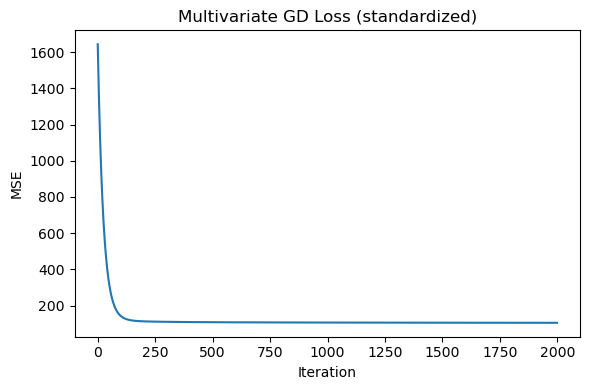

In [13]:
# Loss curve (MSE over iterations)
plt.figure(figsize=(6,4))
plt.plot(range(len(loss_hist)), loss_hist)
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("Multivariate GD Loss (standardized)")
plt.tight_layout()
plt.show()

### Q2.4 Set 2 (Raw predictors, all 8 features)
Raw features require a much smaller learning rate. We search a few small values and pick the best training R².

In [14]:
rates = [1e-12, 1e-11, 1e-10, 1e-9, 1e-8]

Xtr_raw = X_train.to_numpy(dtype=float)
Xte_raw = X_test.to_numpy(dtype=float)

best = None
for lr in rates:
    w, b = gd_multivariate(Xtr_raw, y_train, alpha=lr, n_iter=5000, return_history=False)
    if np.any(np.isnan(w)) or np.isnan(b):
        continue

    yhat_tr = Xtr_raw @ w + b
    yhat_te = Xte_raw @ w + b

    if (np.any(np.isnan(yhat_tr)) or np.any(np.isinf(yhat_tr)) or
        np.any(np.isnan(yhat_te)) or np.any(np.isinf(yhat_te))):
        continue

    row = {
        "lr": lr,
        "w": w,
        "b": b,
        "train_MSE": mse(y_train, yhat_tr),
        "train_R2": r2(y_train, yhat_tr),
        "test_MSE": mse(y_test, yhat_te),
        "test_R2": r2(y_test, yhat_te),
    }

    if (best is None) or (row["train_R2"] > best["train_R2"]):
        best = row

best

{'lr': 1e-08,
 'w': array([ 0.06044672,  0.027113  , -0.00356006, -0.0034633 ,  0.00329474,
         0.01078513,  0.00906114,  0.02949249]),
 'b': np.float64(3.044570650708402e-05),
 'train_MSE': 180.92631971912746,
 'train_R2': np.float64(0.3470257413922112),
 'test_MSE': 256.77793691523374,
 'test_R2': np.float64(-0.17929126256488104)}

## Part C — Regression Analysis (OLS with p-values)
We fit multivariate OLS on the **training** set, then evaluate on both train/test.

Transform sets:
- **Set 2:** raw predictors
- **Set 1:** standardized predictors (same standardization as Part B)
- **Set 3:** log(x+1) predictors

In [15]:
def fit_ols_and_eval(Xtr, ytr, Xte, yte):
    Xtr_c = sm.add_constant(Xtr, has_constant="add")
    Xte_c = sm.add_constant(Xte, has_constant="add")
    model = sm.OLS(ytr, Xtr_c).fit()

    yhat_tr = model.predict(Xtr_c)
    yhat_te = model.predict(Xte_c)

    perf = {
        "train_MSE": mse(ytr, yhat_tr),
        "train_R2": r2(ytr, yhat_tr),
        "test_MSE": mse(yte, yhat_te),
        "test_R2": r2(yte, yhat_te),
    }
    return model, perf

# Raw OLS (Set 2)
model_raw, perf_raw = fit_ols_and_eval(Xtr_raw, y_train, Xte_raw, y_test)

perf_raw, model_raw.params, model_raw.pvalues

({'train_MSE': 104.15446393492331,
  'train_R2': np.float64(0.6241001089604974),
  'test_MSE': 141.25799330049705,
  'test_R2': np.float64(0.35125143823506666)},
 array([-5.20353341e+01,  1.32845302e-01,  1.25040377e-01,  1.06739349e-01,
        -1.33135465e-01,  1.16181979e-01,  2.86328753e-02,  3.40841960e-02,
         1.18763355e-01]),
 array([7.08196536e-02, 6.97096932e-41, 4.14518989e-26, 1.89457127e-13,
        1.91841837e-03, 2.46111666e-01, 5.44324111e-03, 2.73812239e-03,
        9.51621857e-74]))

In [16]:
# Standardized OLS (Set 1) — same standardization as Part B
model_std, perf_std = fit_ols_and_eval(Xtr_std, y_train, Xte_std, y_test)
perf_std, model_std.params, model_std.pvalues

({'train_MSE': 104.1544639349233,
  'train_R2': np.float64(0.6241001089604974),
  'test_MSE': 141.25799330049782,
  'test_R2': np.float64(0.3512514382350631)},
 array([36.972     , 14.1033794 , 10.50423047,  6.85625351, -2.96550348,
         0.69421988,  2.22049093,  2.79057911,  7.27836066]),
 array([0.00000000e+00, 6.97096932e-41, 4.14518989e-26, 1.89457127e-13,
        1.91841837e-03, 2.46111666e-01, 5.44324111e-03, 2.73812239e-03,
        9.51621857e-74]))

In [17]:
# Log transform OLS (Set 3): log(x + 1)
Xtr_log = np.log1p(Xtr_raw)
Xte_log = np.log1p(Xte_raw)

model_log, perf_log = fit_ols_and_eval(Xtr_log, y_train, Xte_log, y_test)
perf_log, model_log.params, model_log.pvalues

({'train_MSE': 55.8314885488256,
  'train_R2': np.float64(0.7985007106830324),
  'test_MSE': 54.51984726570401,
  'test_R2': np.float64(0.7496094084670475)},
 array([ 79.81965845,  23.68724875,   2.30805379,   0.20894779,
        -38.28565834,   1.85054143,   4.16618441,  -6.53486609,
          9.03452894]),
 array([2.93770453e-001, 1.29860458e-086, 4.51879000e-036, 2.60534687e-001,
        1.86258617e-020, 1.03969702e-005, 4.07894287e-001, 9.47686639e-002,
        1.74699065e-192]))

### Part C Notes (Compare to Part B)
- OLS should match (or improve) the multivariate fit compared to gradient descent, because it solves the least-squares objective directly.
- Standardization does **not** change the *fit quality* of OLS (predictions) if you include an intercept, but it changes coefficient scales and can help numerical stability.  
- Log(x+1) can change both fit and significance, especially for skewed variables.
